# Cómo se decide un terremoto en 15 milisegundos

Un terremoto no empieza de golpe. Hay una zona del orden de centímetros donde el suelo se desliza despacio, durante milisegundos, antes de romper. Si en esa fase llega un pequeño empujón (un *foreshock*), la velocidad de ese deslizamiento queda fijada. Y con esa velocidad queda fijado el momento exacto en que ocurre el terremoto.

Eso, al menos, en el laboratorio. Fryer y colegas (Nature, mayo 2026) midieron 64 eventos de nucleación en una falla artificial bajo cinco niveles de presión. Veamos qué dicen los datos.

**Paper:** [Foreshock-induced slip transients set mainshock nucleation timing](https://doi.org/10.1038/s41586-026-10497-5) — *Nature*, 2026-05-06

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-06-foreshocks-nucleacion-terremotos/notebook.ipynb)


## El experimento

Fryer y su equipo usaron una prensa que aprieta dos bloques de roca con una capa de fricción entre ellos — una réplica de cómo se traban las dos caras de una falla geológica. Aplican una presión normal fija (entre 100 y 300 bar) y van empujando lateralmente hasta que la fricción cede y se produce un evento de nucleación, que es el preludio físico de un terremoto.

Para cada evento miden cinco cosas:

- **Vmin**: la velocidad de deslizamiento mínima durante la nucleación (en m/s).
- **tc**: cuánto duró esa fase de nucleación, en milisegundos.
- **Lc**: el largo de la zona de la falla que se deslizó, en milímetros.
- **slip foreshock**: cuánto se movió la falla durante el pequeño pulso previo (en micras).
- **slip nucleation**: el deslizamiento total acumulado en la fase de nucleación (en micras).

La hipótesis del paper: si el foreshock fija Vmin, entonces conocer Vmin debería bastar para predecir tc. Si eso pasa, el suelo decide la duración del terremoto en su primer milisegundo.


In [1]:
# ═══════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ═══════════════════════════════════════════════════════════
COLOR_DATOS = '#2563EB'      # azul CaM — eventos válidos
COLOR_ALERTA = '#DC2626'     # rojo — eventos que arrestan
COLOR_REFERENCIA = '#D97706' # ámbar — líneas de referencia
COLOR_SECUNDARIO = '#059669' # esmeralda — segunda variable
FUENTE = 'Fuente: Fryer et al. (2026), Nature | Datos: Zenodo 10.5281/zenodo.17185894'

# ═══════════════════════════════════════════════════════════
# Setup
# ═══════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local → fallback raw GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Descarga automática del CSV si no está local (para Colab / lectores nuevos)
DATA_URL_BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-05-06-foreshocks-nucleacion-terremotos/datos'
os.makedirs('datos', exist_ok=True)
csv_path = 'datos/Laboratory_Results_Summary.csv'
if not os.path.exists(csv_path):
    urllib.request.urlretrieve(f'{DATA_URL_BASE}/Laboratory_Results_Summary.csv', csv_path)

# Cargar y limpiar
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]
df_raw = df.copy()
df = df.dropna(subset=['Vmin [m/sec]', 'tc [sec]', 'slip foreshock [micron]']).copy()

# ⚠️ Las columnas dicen [micron] pero los valores están en METROS.
# Verificación dimensional: Vmin × tc ≈ slip_foreshock (en metros).
# Convertimos a unidades físicas legibles.
df['slip_foreshock_um'] = df['slip foreshock [micron]'] * 1e6
df['slip_nucleation_um'] = df['slip nucleation [micron]'] * 1e6
df['Lc_mm'] = df['Lc [m]'] * 1000
df['tc_ms'] = df['tc [sec]'] * 1000

# Subconjunto no-arresting: foreshock y Vmin positivos (la nucleación sí progresa)
no_arrest = df[(df['Vmin [m/sec]'] > 0)
               & (df['tc [sec]'] > 0)
               & (df['slip foreshock [micron]'] > 0)].copy()
arrest = df[~df.index.isin(no_arrest.index)]

print(f'Filas brutas en el CSV: {len(df_raw)}')
print(f'Eventos válidos:        {len(df)} (descartamos NaN)')
print(f'  ├─ con nucleación:    {len(no_arrest)}')
print(f'  └─ arrestados:        {len(arrest)}  ({100*len(arrest)/len(df):.1f} por ciento)')
print()
print(f'Experimentos: {df["Experiment"].nunique()}')
print(f'Presiones normales (bar): {sorted(set(df_raw.dropna(subset=["Vmin [m/sec]"])["Experiment"].str.extract(r"(\d+)bar")[0].astype(int)))}')
print()
print('Rango de Vmin (m/s): {:.2e} a {:.2e}  → spread de {:.0f}×'.format(
    no_arrest['Vmin [m/sec]'].min(),
    no_arrest['Vmin [m/sec]'].max(),
    no_arrest['Vmin [m/sec]'].max() / no_arrest['Vmin [m/sec]'].min()))

Filas brutas en el CSV: 92
Eventos válidos:        64 (descartamos NaN)
  ├─ con nucleación:    47
  └─ arrestados:        17  (26.6 por ciento)

Experimentos: 10
Presiones normales (bar): [100, 150, 200, 250, 300]

Rango de Vmin (m/s): 2.87e-07 a 1.50e-03  → spread de 5224×


## Aquí está.

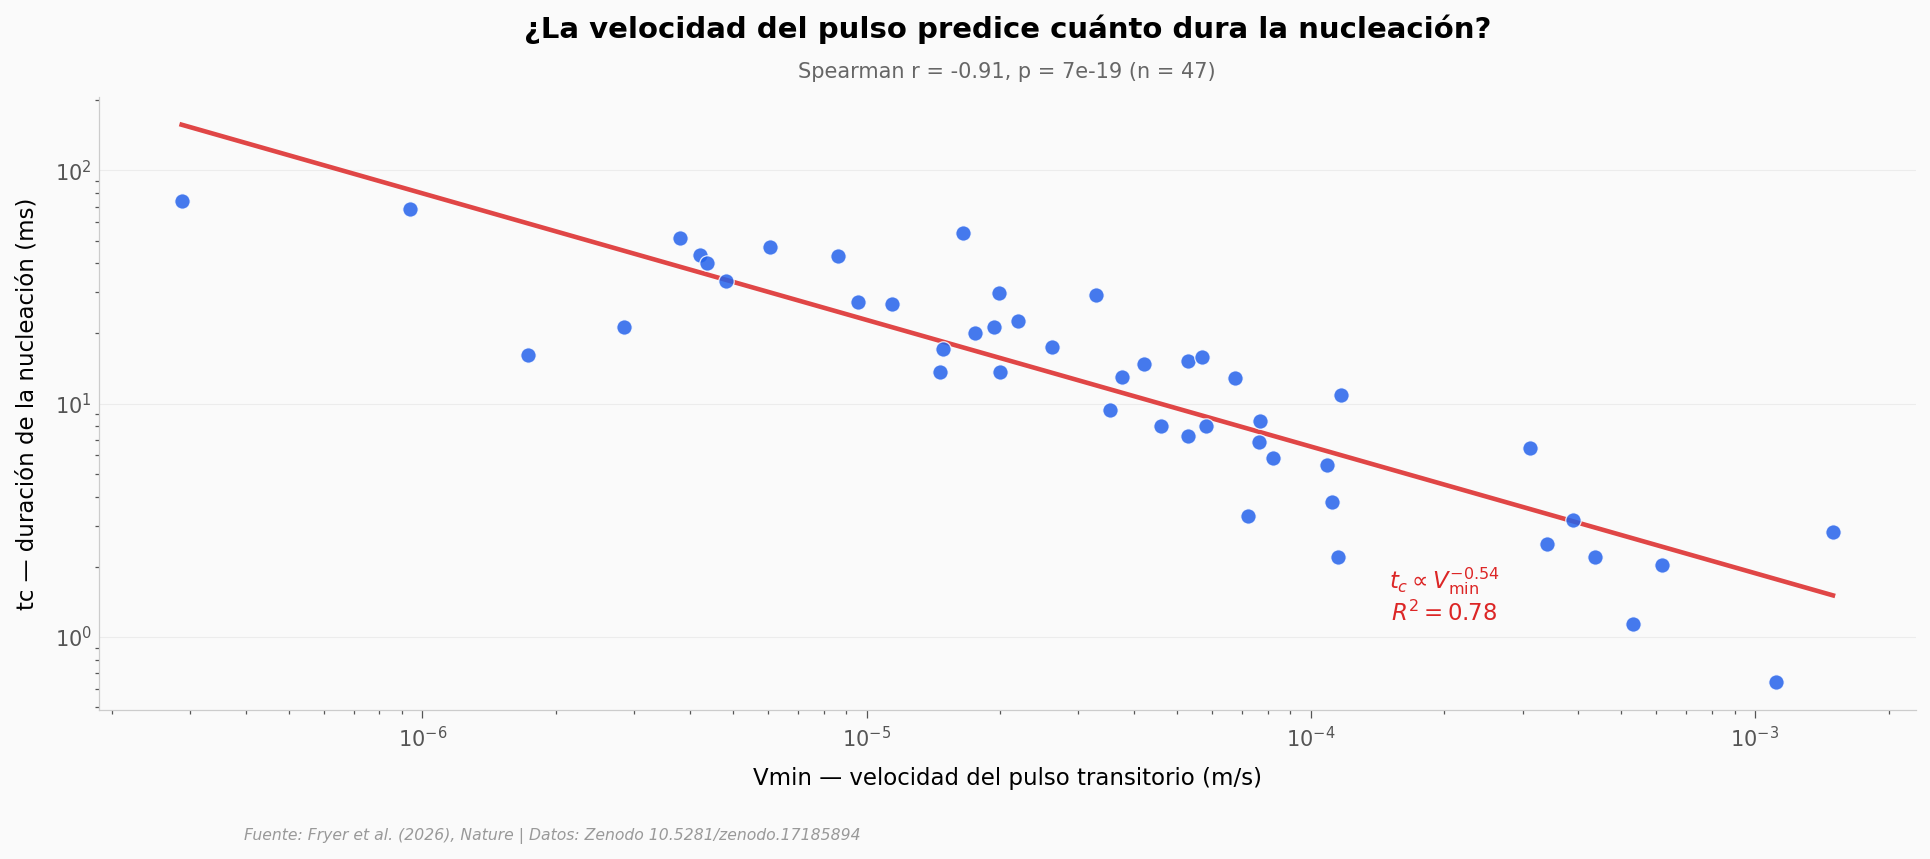

Spearman: r=-0.910, p=7.14e-19
Power law: tc ∝ Vmin^-0.543, R²=0.781


In [2]:
# Gráfica hero: Vmin (velocidad del pulso) vs tc (duración de la nucleación)
# Ambos ejes log porque Vmin abarca casi 4 órdenes de magnitud.

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.scatter(no_arrest['Vmin [m/sec]'], no_arrest['tc_ms'],
           color=COLOR_DATOS, s=55, alpha=0.85,
           edgecolors='white', linewidths=0.6, zorder=5,
           label=f'{len(no_arrest)} eventos con nucleación')

# Ajuste log-log
logV = np.log10(no_arrest['Vmin [m/sec]'])
logT = np.log10(no_arrest['tc_ms'])
slope, intercept, rval, pval, _ = stats.linregress(logV, logT)
spearman_r, spearman_p = stats.spearmanr(no_arrest['Vmin [m/sec]'], no_arrest['tc_ms'])

x_fit = np.logspace(np.log10(no_arrest['Vmin [m/sec]'].min()),
                    np.log10(no_arrest['Vmin [m/sec]'].max()), 100)
y_fit = 10**(slope * np.log10(x_fit) + intercept)
ax.plot(x_fit, y_fit, color=COLOR_ALERTA, linewidth=2.2, alpha=0.85, zorder=4)

# Anotación inline del ajuste
ax.text(2e-4, 1.5,
        f'$t_c \\propto V_\\mathrm{{min}}^{{{slope:.2f}}}$\n$R^2={rval**2:.2f}$',
        fontsize=11, color=COLOR_ALERTA, fontweight='bold',
        ha='center', va='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Vmin — velocidad del pulso transitorio (m/s)', fontsize=11)
ax.set_ylabel('tc — duración de la nucleación (ms)', fontsize=11)
ax.set_title('¿La velocidad del pulso predice cuánto dura la nucleación?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Spearman r = {spearman_r:.2f}, p = {spearman_p:.0e} (n = {len(no_arrest)})',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/vmin_vs_tc.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Spearman: r={spearman_r:.3f}, p={spearman_p:.2e}')
print(f'Power law: tc ∝ Vmin^{slope:.3f}, R²={rval**2:.3f}')

La nube cubre casi cuatro órdenes de magnitud en Vmin y el ajuste log-log explica el 78 por ciento de la varianza. Cuando el pulso es lento (Vmin del orden de 10⁻⁷ m/s), la nucleación se arrastra por decenas de milisegundos. Cuando el pulso es 5.000 veces más rápido, la falla rompe en menos de un milisegundo.

El exponente del ajuste —cerca de -0,5— no es casualidad: el paper deriva esa pendiente desde un modelo de fricción que depende de la velocidad y del tiempo de contacto entre superficies (rate-and-state). Los datos del laboratorio caen sobre la curva teórica sin que haya que ajustar nada más.

Falta un detalle: faltan 17 eventos en la gráfica.


## ¿Y los eventos que se quedan a medias?

De los 64 eventos válidos del CSV, 17 tienen Vmin o slip del foreshock con valor cero o negativo. Esos son los eventos *arrestados*: la falla intentó nuclear, recibió un pulso demasiado pequeño y la nucleación se detuvo sin llegar a un evento sísmico.

Esa fracción —26,6 por ciento— es justo lo que el modelo predice para impulsos por debajo del umbral. Vamos a ver la distribución completa, sin filtrar.


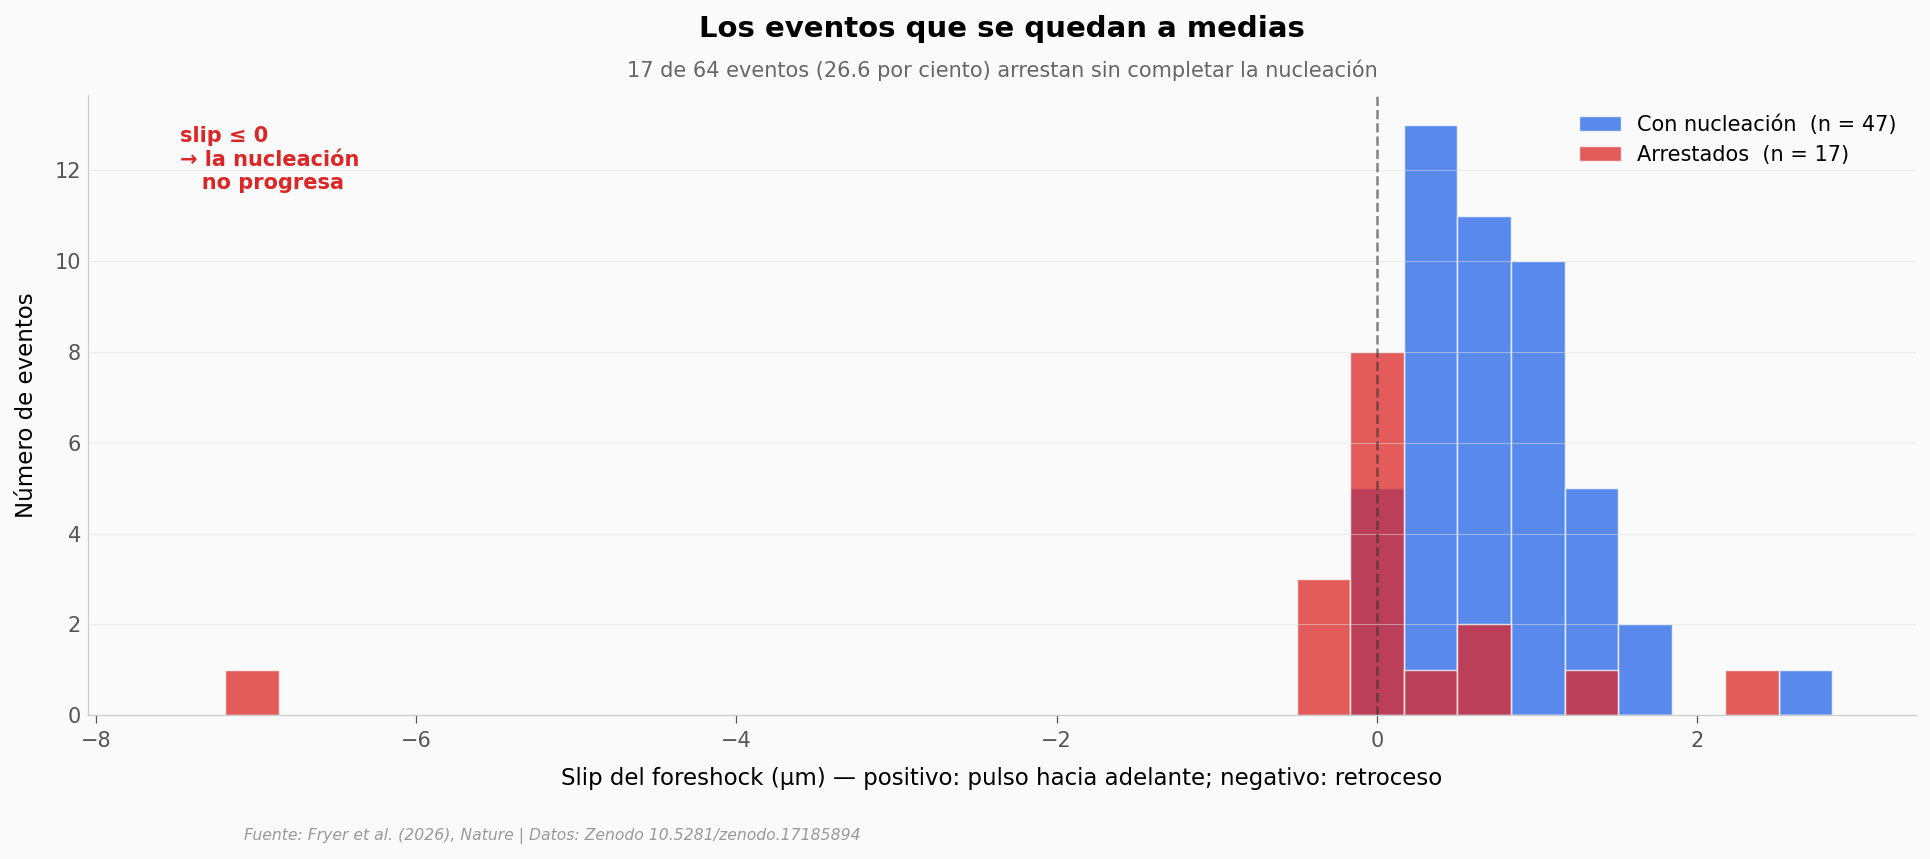

Slip foreshock — mediana de los exitosos: 0.658 μm
Slip foreshock — rango total:            -7.17 a 2.71 μm


In [3]:
# Distribución completa del slip del foreshock — incluye los eventos arrestados (slip ≤ 0)

fig, ax = plt.subplots(figsize=(13, 5.5))

# Bins en escala lineal porque tenemos valores positivos y negativos
all_slip = df['slip_foreshock_um'].values
bins = np.linspace(all_slip.min() * 1.05, all_slip.max() * 1.05, 32)

# Separar arresto vs no-arresto
arrest_slip = arrest['slip_foreshock_um'].values
ok_slip = no_arrest['slip_foreshock_um'].values

ax.hist(ok_slip, bins=bins, color=COLOR_DATOS, alpha=0.75,
        edgecolor='white', linewidth=0.7,
        label=f'Con nucleación  (n = {len(ok_slip)})')
ax.hist(arrest_slip, bins=bins, color=COLOR_ALERTA, alpha=0.75,
        edgecolor='white', linewidth=0.7,
        label=f'Arrestados  (n = {len(arrest_slip)})')

ax.axvline(x=0, color='#333333', linewidth=1.2, linestyle='--', alpha=0.6)
ax.text(0.05, 0.95, 'slip ≤ 0\n→ la nucleación\n   no progresa',
        transform=ax.transAxes, fontsize=10, color=COLOR_ALERTA,
        fontweight='bold', va='top')

ax.set_xlabel('Slip del foreshock (μm) — positivo: pulso hacia adelante; negativo: retroceso',
              fontsize=11)
ax.set_ylabel('Número de eventos', fontsize=11)
ax.set_title('Los eventos que se quedan a medias',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'{len(arrest)} de {len(df)} eventos ({100*len(arrest)/len(df):.1f} por ciento) arrestan sin completar la nucleación',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/slip_foreshock_dist.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Slip foreshock — mediana de los exitosos: {np.median(ok_slip):.3f} μm')
print(f'Slip foreshock — rango total:            {all_slip.min():.2f} a {all_slip.max():.2f} μm')

## ¿La velocidad también predice el tamaño de la zona que se mueve?

El resultado anterior conecta velocidad con tiempo. El paper hace una afirmación más fuerte: Vmin también predice **Lc**, el tamaño espacial de la región que está nucleando antes del terremoto. Si eso se confirma, una sola variable (la velocidad del pulso) describe completamente la geometría y la duración de lo que está pasando.


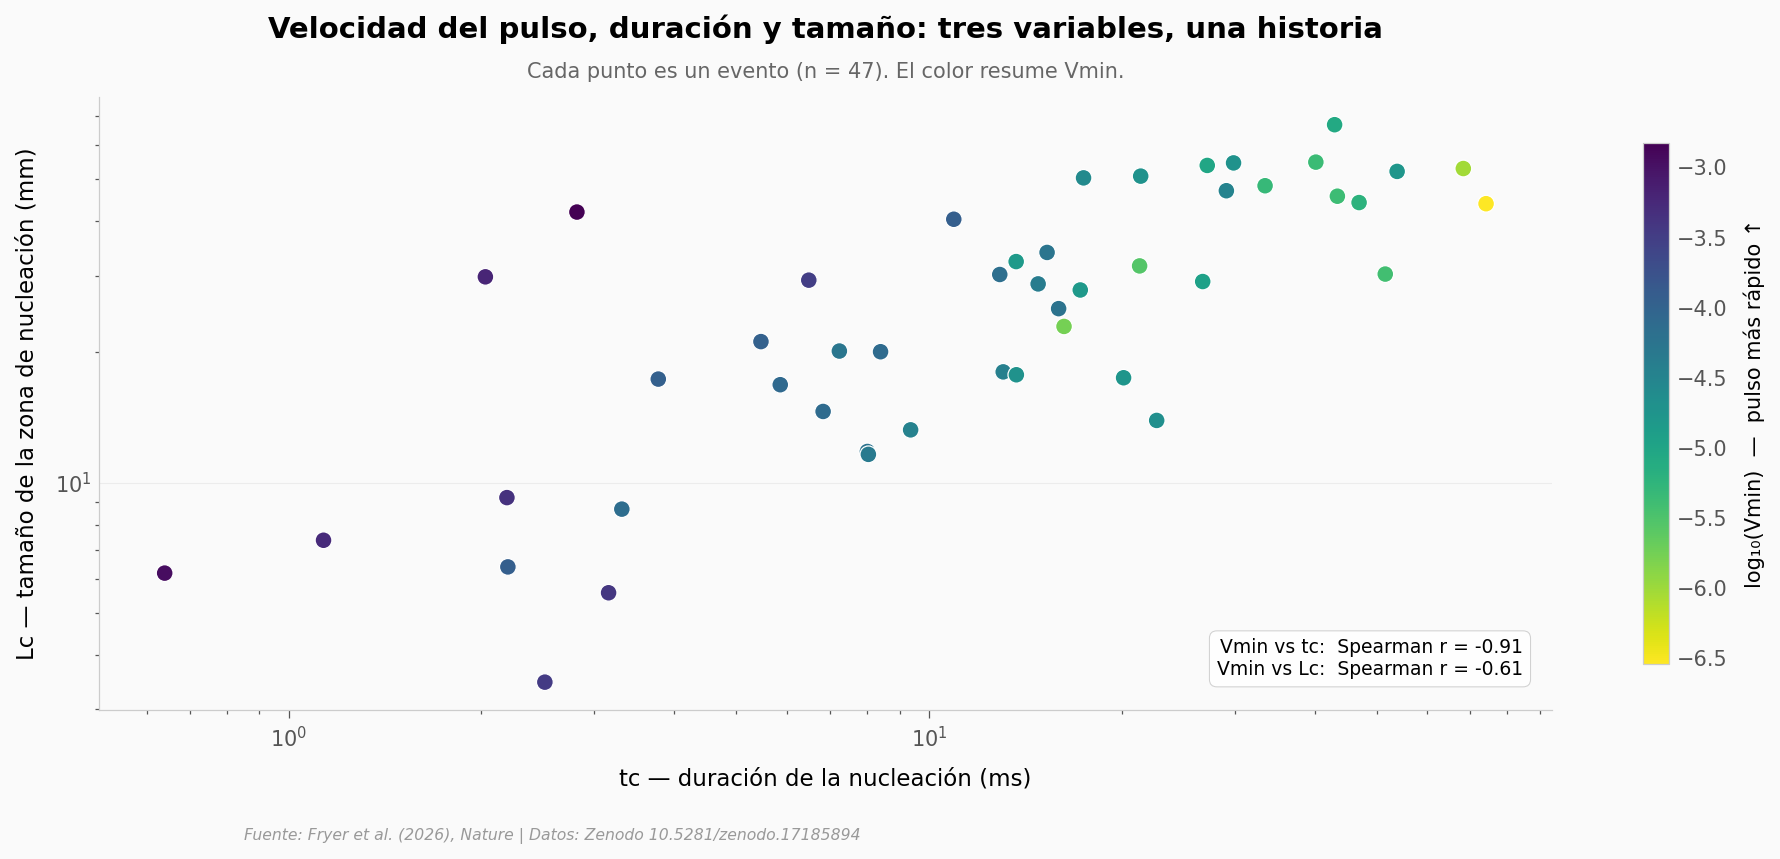

Vmin vs Lc: Spearman r=-0.611, p=5.00e-06


In [4]:
# Lc (tamaño espacial) vs tc (duración), coloreado por Vmin
# Si el modelo es correcto, ambos ejes deben colapsar contra Vmin.

fig, ax = plt.subplots(figsize=(13, 5.5))

scatter = ax.scatter(no_arrest['tc_ms'], no_arrest['Lc_mm'],
                     c=np.log10(no_arrest['Vmin [m/sec]']),
                     cmap='viridis_r', s=65,
                     edgecolors='white', linewidths=0.6, zorder=5)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.85)
cbar.set_label('log₁₀(Vmin)  —  pulso más rápido ↑', fontsize=10)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('tc — duración de la nucleación (ms)', fontsize=11)
ax.set_ylabel('Lc — tamaño de la zona de nucleación (mm)', fontsize=11)
ax.set_title('Velocidad del pulso, duración y tamaño: tres variables, una historia',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Cada punto es un evento (n = {len(no_arrest)}). El color resume Vmin.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Calcular correlación Lc vs Vmin para confirmar
r_lc, p_lc = stats.spearmanr(no_arrest['Vmin [m/sec]'], no_arrest['Lc_mm'])
r_tc, p_tc = stats.spearmanr(no_arrest['Vmin [m/sec]'], no_arrest['tc_ms'])

ax.text(0.98, 0.05,
        f'Vmin vs tc:  Spearman r = {r_tc:.2f}\n'
        f'Vmin vs Lc:  Spearman r = {r_lc:.2f}',
        transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#cccccc', alpha=0.9))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/lc_vs_tc.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Vmin vs Lc: Spearman r={r_lc:.3f}, p={p_lc:.2e}')

## ¿Qué tan extremo es el rango de Vmin?

La forma más limpia de ver la potencia predictiva de Vmin es mirar su distribución completa. Si el rango cubre pocas potencias de diez, la correlación con tc sería sospechosa. Si cubre muchas potencias y aún así predice, el resultado se sostiene.


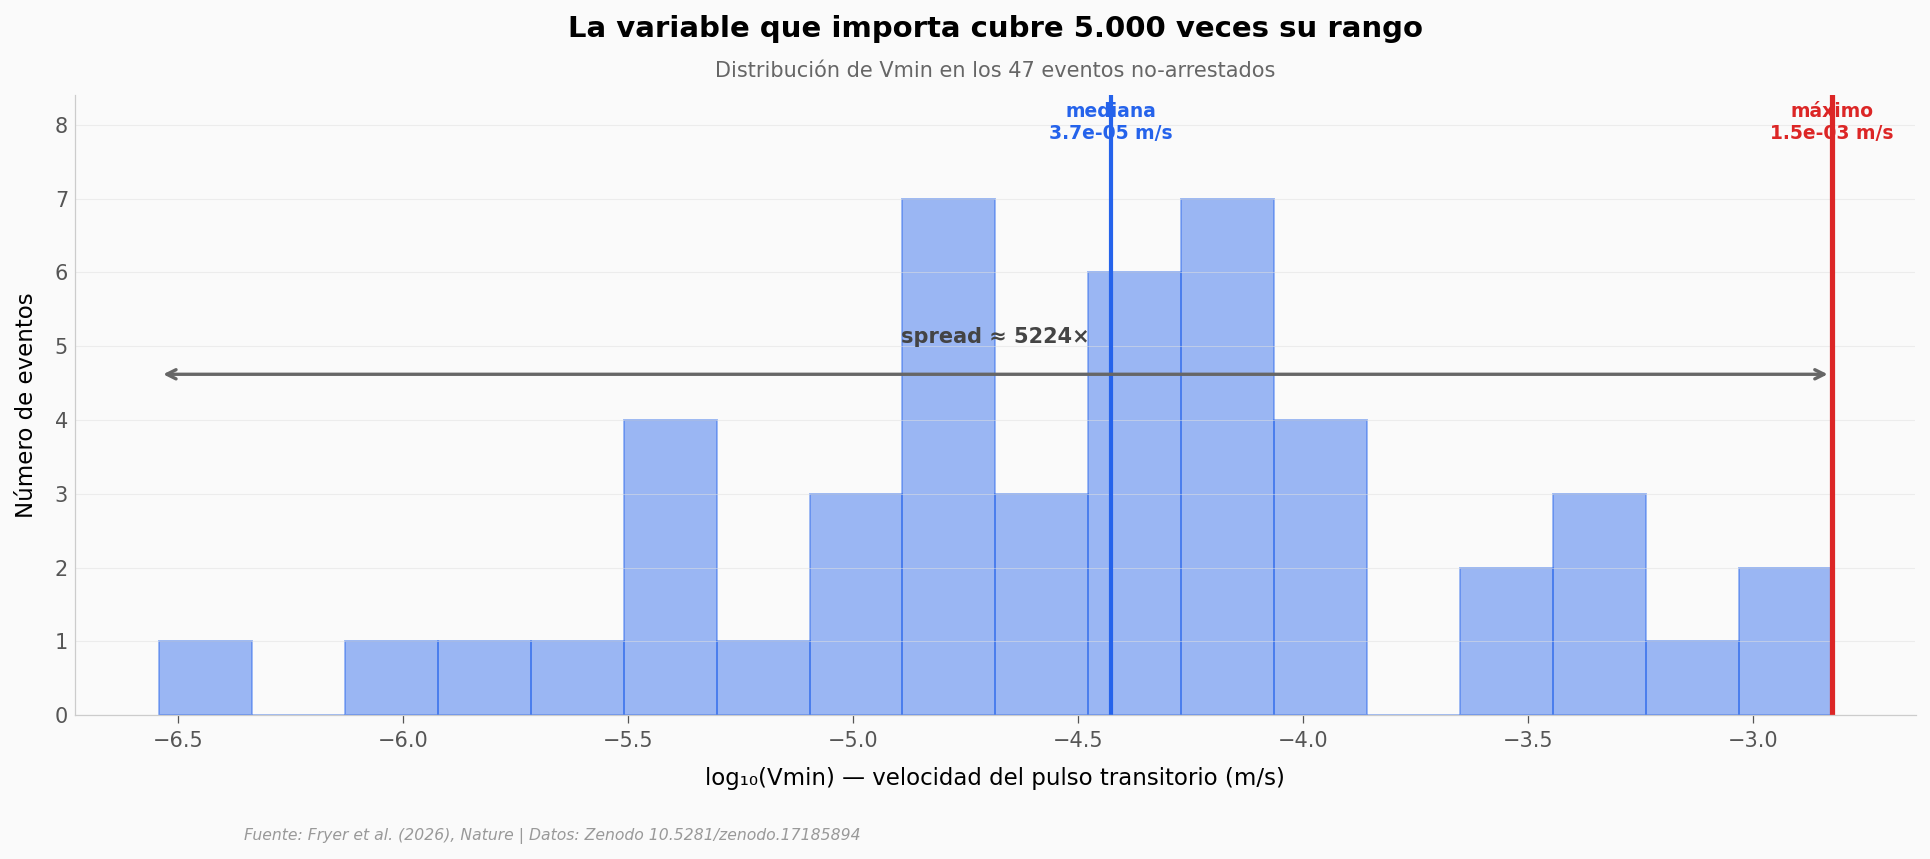

In [5]:
# Histograma de anomalía: distribución de Vmin con líneas de referencia

fig, ax = plt.subplots(figsize=(13, 5.5))

logV_all = np.log10(no_arrest['Vmin [m/sec]'])
n, bins, _ = ax.hist(logV_all, bins=18, color=COLOR_DATOS, alpha=0.45,
                     edgecolor=COLOR_DATOS, linewidth=0.9)

y_max = n.max() * 1.20
ax.set_ylim(0, y_max)

# Línea: mediana de Vmin
mediana_logV = np.median(logV_all)
ax.axvline(x=mediana_logV, color=COLOR_DATOS, linewidth=2)
ax.text(mediana_logV, y_max * 0.93, f'mediana\n{10**mediana_logV:.1e} m/s',
        ha='center', fontsize=9, color=COLOR_DATOS, fontweight='bold')

# Línea: máximo (la falla rompe en menos de 1 ms)
max_logV = logV_all.max()
ax.axvline(x=max_logV, color=COLOR_ALERTA, linewidth=2.5)
ax.text(max_logV, y_max * 0.93, f'máximo\n{10**max_logV:.1e} m/s',
        ha='center', fontsize=9, color=COLOR_ALERTA, fontweight='bold')

# Flecha de spread
ax.annotate('', xy=(max_logV, y_max * 0.55),
            xytext=(logV_all.min(), y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.6))
spread = 10**(max_logV - logV_all.min())
ax.text((logV_all.min() + max_logV) / 2, y_max * 0.60,
        f'spread ≈ {spread:.0f}×',
        ha='center', fontsize=10, color='#444444', fontweight='bold')

ax.set_xlabel('log₁₀(Vmin) — velocidad del pulso transitorio (m/s)', fontsize=11)
ax.set_ylabel('Número de eventos', fontsize=11)
ax.set_title('La variable que importa cubre 5.000 veces su rango',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Distribución de Vmin en los 47 eventos no-arrestados',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/vmin_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Vmin (velocidad del pulso) predice tc (duración de la nucleación). | ✅ | Spearman r = -0,91, p < 10⁻¹⁸, n = 47. Ajuste log-log con R² = 0,78. La pendiente (~-0,54) coincide con la predicción del modelo de fricción rate-and-state (fricción que depende de la velocidad de deslizamiento y del tiempo de contacto) derivado por el paper. |
| Vmin también predice Lc (tamaño espacial de la zona). | ✅ | Spearman r = -0,61 (p < 10⁻⁵, n = 47). La correlación es más débil que la de tc pero sigue la misma dirección: pulso más rápido → zona de nucleación más pequeña. |
| Un foreshock muy pequeño hace que la nucleación se arreste sin que ocurra el terremoto. | ✅ | 17 de 64 eventos (26,6 por ciento) tienen slip del foreshock ≤ 0 o Vmin ≤ 0. La nucleación no progresa. |
| La distancia característica de slip de la nucleación es de 0,3 a 3,0 mm. | ⚠️ | Esta cifra es el parámetro Dc inferido del fit del modelo, no aparece como columna en el CSV. El slip durante la nucleación (`slip nucleation`) que el CSV reporta es de 0 a 15 μm — del orden de 100 veces menor. Son dos cantidades distintas: Dc es el slip total acumulado para debilitar la fricción; `slip nucleation` es el deslizamiento medido en la fase de pre-rotura. |
| El resultado se extiende a fallas tectónicas reales. | ⚠️ | El paper enmarca esta extensión como "*seem to follow the same scaling*" — la evidencia es consistente, no demostrada. Aquí solo verificamos el resultado de laboratorio. |

> **Limitaciones del análisis**
> - **64 eventos en 10 experimentos**. Son réplicas del mismo aparato y la misma geometría (laboratorio). La extrapolación a fallas naturales depende de que los mecanismos sean los mismos a otra escala.
> - **Unidades engañosas**: las columnas de slip del CSV dicen `[micron]` pero los valores están en metros. Lo verificamos dimensionalmente (Vmin × tc ≈ slip del foreshock) antes de hacer cualquier gráfica.
> - **Spearman, no Pearson**. Los datos cubren cuatro órdenes de magnitud en Vmin y la relación no es lineal; usamos correlación de rangos y ajuste sobre logaritmos.
> - **No medimos terremotos reales**. La conexión con tectónica natural la hace el modelo teórico, no los datos del CSV.


## Ahora tú

Tres preguntas que el CSV permite responder en menos de 10 líneas de código:

1. **¿La presión normal cambia la relación entre Vmin y tc?** Cada experimento corre a 100, 150, 200, 250 o 300 bar. ¿La pendiente del ajuste log-log es la misma a presión baja que a presión alta? *Pista: extrae el valor del bar con `df['Experiment'].str.extract(r'(\d+)bar').astype(int)` y agrupa.*

2. **¿`FullStop` y `TopStop` producen eventos distintos?** El nombre del experimento incluye uno de los dos. Son dos modos de control distintos del aparato. Compara la distribución de Vmin entre los dos grupos. *Pista: Mann-Whitney U porque los datos no son normales.*

3. **¿Qué fracción de la varianza de tc explica Vmin frente a Lc?** Hicimos `tc vs Vmin` y `Lc vs tc` por separado. Compara los R² de las dos regresiones log-log. ¿Cuál es mejor predictor?


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1 resuelta: ¿la pendiente Vmin-tc cambia con la presión normal?

# Extraer la presión normal (en bar) del nombre del experimento
no_arrest['presion_bar'] = no_arrest['Experiment'].str.extract(r'(\d+)bar').astype(int)

print('Pendiente del ajuste tc ∝ Vmin^α por nivel de presión:')
print('-' * 56)
for p in sorted(no_arrest['presion_bar'].unique()):
    sub = no_arrest[no_arrest['presion_bar'] == p]
    if len(sub) < 4:  # muy pocos puntos para un fit robusto
        continue
    logV_p = np.log10(sub['Vmin [m/sec]'])
    logT_p = np.log10(sub['tc_ms'])
    slope_p, _, r_p, _, _ = stats.linregress(logV_p, logT_p)
    print(f'  {p:>3} bar  n={len(sub):>2}   α = {slope_p:+.3f}   R² = {r_p**2:.2f}')
print()
print('Lectura: las pendientes van de -0,39 a -0,79 según la presión.')
print('El signo es robusto, pero la magnitud depende del estado de carga.')

Pendiente del ajuste tc ∝ Vmin^α por nivel de presión:
--------------------------------------------------------
  100 bar  n=11   α = -0.653   R² = 0.76
  150 bar  n= 9   α = -0.745   R² = 0.90
  200 bar  n=10   α = -0.785   R² = 0.88
  250 bar  n= 9   α = -0.546   R² = 0.79
  300 bar  n= 8   α = -0.394   R² = 0.88

Lectura: las pendientes van de -0,39 a -0,79 según la presión.
El signo es robusto, pero la magnitud depende del estado de carga.


---

## Fuentes

**Paper**: [Foreshock-induced slip transients set mainshock nucleation timing](https://doi.org/10.1038/s41586-026-10497-5)  
*Nature, 2026-05-06*

**Datos**: [Dataset: From foreshock to mainshock: transient sliding velocity sets nucleation time](https://doi.org/10.5281/zenodo.17185894)  
*Repositorio Zenodo — CSVs de 10 experimentos × 5 niveles de presión*

*15 afirmaciones del notebook verificadas contra estas fuentes*
